In [ ]:
# import 

In [26]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [27]:
df= pd.read_csv("bowling_stats.csv",index_col=[0])

In [28]:
df

,bowler,team,matches,innings,wickets,economy,impact,bbi,overs,balls,dot_balls,maiden_overs,runs,avg,4wh,5wh
position,,,,,,,,,,,,,,,,
1,Bhuvneshwar Kumar,RCB,8,8,14,7.61,351.0,3--5,31.0,186,72,0,236,16.85,0,0
2,Anshul Kamboj,CSK,8,8,14,8.56,284.8,3--22,27.4,166,75,0,237,16.92,0,0
3,Eshan Malinga,SRH,8,8,14,9.44,293.1,4--32,27.0,162,61,0,255,18.21,1,0
4,Jofra Archer,RR,8,8,13,8.03,343.0,3--20,29.0,174,88,1,233,17.92,0,0
5,Prince Yadav,LSG,8,8,13,8.06,355.8,3--32,30.0,180,77,0,242,18.61,0,0
6,Kagiso Rabada,GT,8,8,13,9.48,385.1,3--25,31.0,186,79,0,294,22.61,0,0
7,Prasidh Krishna,GT,7,7,12,10.34,243.9,4--28,26.0,156,53,0,269,22.41,1,0
8,Ravi Bishnoi,RR,8,8,11,9.54,232.9,4--41,24.0,144,40,0,229,20.81,1,0
9,Mohsin Khan,LSG,4,4,9,6.37,276.4,5--23,16.0,96,49,3,102,11.33,0,1


### Data  preprocessing

In [29]:
df.dtypes

bowler              str
team                str
matches           int64
innings           int64
wickets           int64
economy         float64
impact          float64
bbi                 str
overs           float64
balls             int64
dot_balls         int64
maiden_overs      int64
runs              int64
avg             float64
4wh               int64
5wh               int64
dtype: object

In [30]:
# Inforamtion about data set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 1 to 15
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   bowler        15 non-null     str    
 1   team          15 non-null     str    
 2   matches       15 non-null     int64  
 3   innings       15 non-null     int64  
 4   wickets       15 non-null     int64  
 5   economy       15 non-null     float64
 6   impact        15 non-null     float64
 7   bbi           15 non-null     str    
 8   overs         15 non-null     float64
 9   balls         15 non-null     int64  
 10  dot_balls     15 non-null     int64  
 11  maiden_overs  15 non-null     int64  
 12  runs          15 non-null     int64  
 13  avg           15 non-null     float64
 14  4wh           15 non-null     int64  
 15  5wh           15 non-null     int64  
dtypes: float64(4), int64(9), str(3)
memory usage: 2.3 KB


In [31]:
# Describe data set 
df.describe()

,matches,innings,wickets,economy,impact,overs,balls,dot_balls,maiden_overs,runs,avg,4wh,5wh
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.00000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,7.400000,7.266667,11.000000,8.782000,275.333333,26.046667,156.466667,62.60000,0.266667,230.200000,21.443333,0.333333,0.066667
std,1.242118,1.222799,2.360387,1.121881,59.676780,4.557704,27.257677,16.32614,0.798809,50.007428,5.537231,0.487950,0.258199
min,4.000000,4.000000,8.000000,6.370000,188.200000,16.000000,96.000000,37.00000,0.000000,102.000000,11.330000,0.000000,0.000000
25%,7.500000,7.000000,9.000000,7.980000,230.400000,25.000000,150.000000,51.00000,0.000000,229.500000,18.065000,0.000000,0.000000
50%,8.000000,8.000000,11.000000,8.850000,273.300000,27.000000,162.000000,61.00000,0.000000,237.000000,20.550000,0.000000,0.000000
75%,8.000000,8.000000,13.000000,9.580000,318.050000,29.000000,174.000000,76.00000,0.000000,257.500000,24.580000,1.000000,0.000000
max,8.000000,8.000000,14.000000,10.340000,385.100000,31.000000,186.000000,88.00000,3.000000,294.000000,32.000000,1.000000,1.000000


In [32]:
# first 7 rows
df.head(7)

,bowler,team,matches,innings,wickets,economy,impact,bbi,overs,balls,dot_balls,maiden_overs,runs,avg,4wh,5wh
position,,,,,,,,,,,,,,,,
1,Bhuvneshwar Kumar,RCB,8,8,14,7.61,351.0,3--5,31.0,186,72,0,236,16.85,0,0
2,Anshul Kamboj,CSK,8,8,14,8.56,284.8,3--22,27.4,166,75,0,237,16.92,0,0
3,Eshan Malinga,SRH,8,8,14,9.44,293.1,4--32,27.0,162,61,0,255,18.21,1,0
4,Jofra Archer,RR,8,8,13,8.03,343.0,3--20,29.0,174,88,1,233,17.92,0,0
5,Prince Yadav,LSG,8,8,13,8.06,355.8,3--32,30.0,180,77,0,242,18.61,0,0
6,Kagiso Rabada,GT,8,8,13,9.48,385.1,3--25,31.0,186,79,0,294,22.61,0,0
7,Prasidh Krishna,GT,7,7,12,10.34,243.9,4--28,26.0,156,53,0,269,22.41,1,0


In [33]:
# last 7 rows
df.tail(7)

,bowler,team,matches,innings,wickets,economy,impact,bbi,overs,balls,dot_balls,maiden_overs,runs,avg,4wh,5wh
position,,,,,,,,,,,,,,,,
9,Mohsin Khan,LSG,4,4,9,6.37,276.4,5--23,16.0,96,49,3,102,11.33,0,1
10,Krunal Pandya,RCB,8,8,9,8.85,227.9,2--30,27.0,162,45,0,239,26.55,0,0
11,Kartik Tyagi,KKR,8,7,9,9.62,211.5,3--22,27.0,162,62,0,260,28.88,0,0
12,Jamie Overton,CSK,7,7,9,9.73,188.2,4--18,19.0,114,37,0,185,20.55,1,0
13,Vaibhav Arora,KKR,8,7,9,10.28,225.2,2--24,28.0,168,60,0,288,32.00,0,0
14,Josh Hazlewood,RCB,5,5,8,7.89,237.9,4--12,19.3,117,55,0,154,19.25,1,0
15,Mohammed Siraj,GT,8,8,8,7.93,273.3,2--23,29.0,174,86,0,230,28.75,0,0


In [34]:
df.isnull().sum()

bowler          0
team            0
matches         0
innings         0
wickets         0
economy         0
impact          0
bbi             0
overs           0
balls           0
dot_balls       0
maiden_overs    0
runs            0
avg             0
4wh             0
5wh             0
dtype: int64

In [35]:
df.duplicated()

position
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
dtype: bool

## EDA Analysis

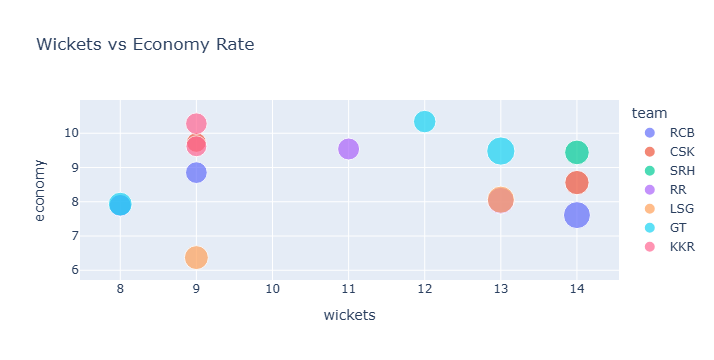

In [56]:
import plotly.express as px
fig = px.scatter(df, x="wickets", y="economy", color="team", size="impact",
                 title="Wickets vs Economy Rate")
fig.show()


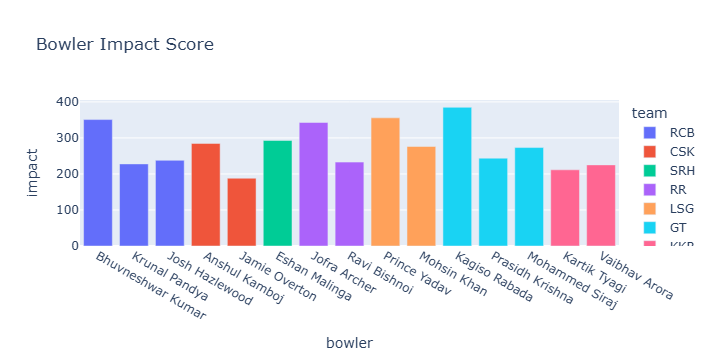

In [57]:
fig = px.bar(df, x="bowler", y="impact", color="team",
             title="Bowler Impact Score")
fig.show()


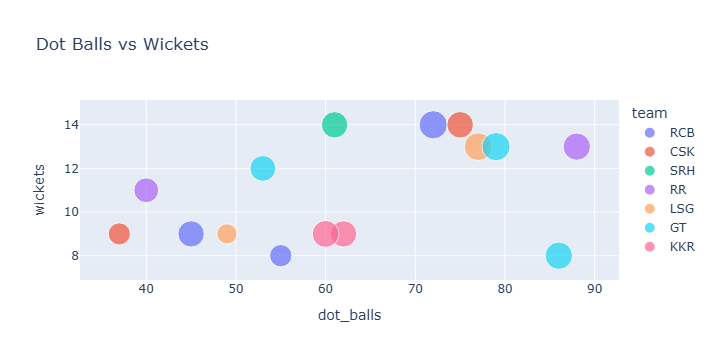

In [58]:
fig = px.scatter(df, x="dot_balls", y="wickets", size="overs", color="team",
                 title="Dot Balls vs Wickets")
fig.show()


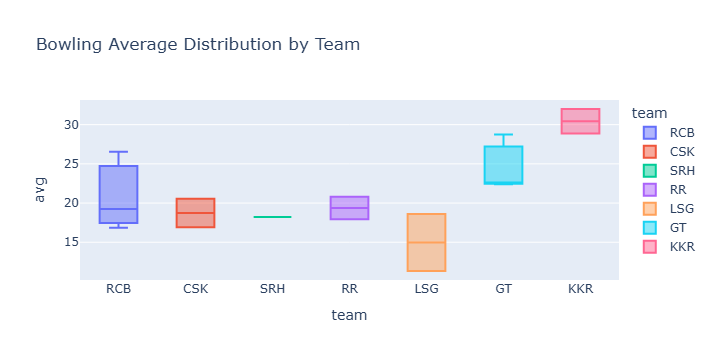

In [59]:
fig = px.box(df, x="team", y="avg", color="team",
             title="Bowling Average Distribution by Team")
fig.show()


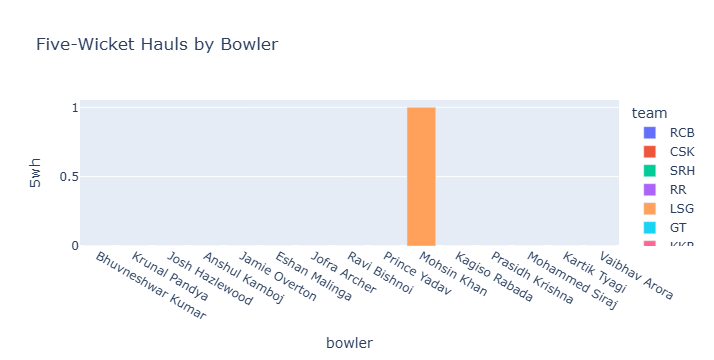

In [60]:
fig = px.bar(df, x="bowler", y="5wh", color="team", title="Five-Wicket Hauls by Bowler")
fig.show()


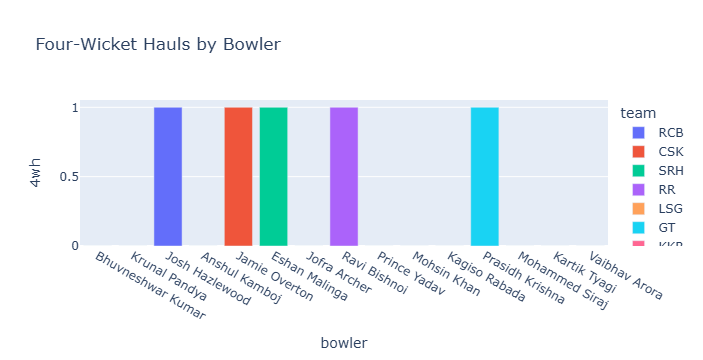

In [61]:
fig = px.bar(df, x="bowler", y="4wh", color="team", title="Four-Wicket Hauls by Bowler")
fig.show()


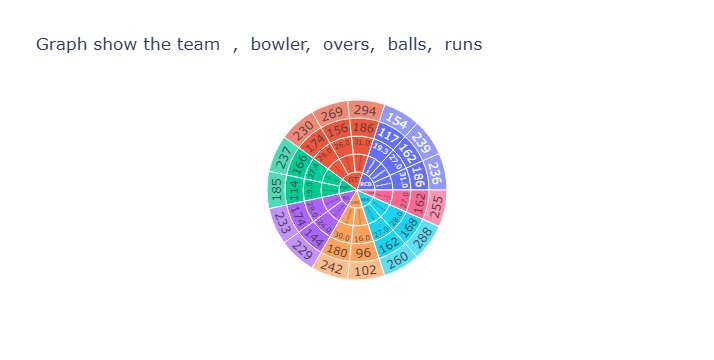

In [62]:
## sunburst Graph
fig = px.sunburst(df,path=["team","bowler","overs","balls","runs"],title="Graph show the team  ,  bowler,  overs,  balls,  runs")
fig.show()

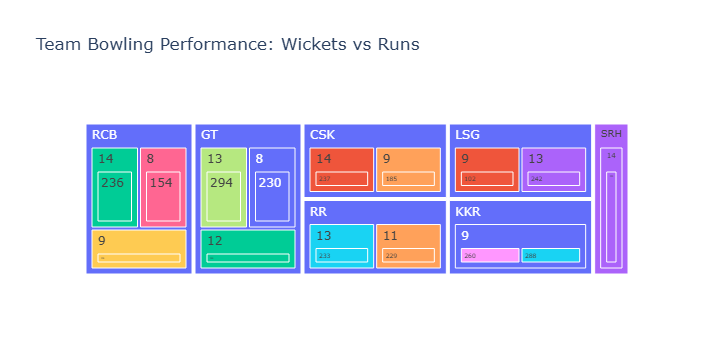

In [64]:
# treemap
fig = px.treemap(df,path=["team","wickets","runs"],color="bowler",title= "Team Bowling Performance: Wickets vs Runs" )
fig.show()